## Portfolio archive and evaluation note

This notebook is retained as part of the original MRI denoising experiment suite. Saved cells and outputs are included so the development work can be reviewed without rerunning long GPU training jobs.

> **Evaluation limitation:** In the supplied workflow, several experiments use the same image directory for both training and validation. The stored metrics are therefore historical development results, not independently reproduced estimates from a held-out validation set. A reliable rerun should use patient-level train, validation, and test splits.

The code was developed in Google Colab and contains hard-coded paths under `/content/drive/MyDrive/Final RI/`. Update those paths before running it with your own dataset.


In [ ]:
# ===========================
#  Cell 1: Rician-Only Noise with Logging (σ=0.03)
# ===========================
import os, cv2, numpy as np, glob, random, zipfile, pandas as pd
from tqdm import tqdm
from google.colab import drive

# --- 1. Mount Google Drive for data access ---
drive.mount('/content/drive')

# --- 2. Extract dataset if not already extracted ---
zip_path = "/content/drive/MyDrive/Final RI/glioma.zip"
extract_path = "/content/drive/MyDrive/Final RI/glioma"
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(" Extracted glioma.zip to:", extract_path)
else:
    print(" glioma/ already exists. Skipping extraction.")

# --- 3. Define clean and Rician-noisy image directories ---
CLEAN_DIR = extract_path
NOISY_DIR = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_vae_rician_0.03"
os.makedirs(NOISY_DIR, exist_ok=True)

# --- 4. Set random seeds for reproducibility ---
random.seed(42)
np.random.seed(42)

# --- 5. Define Rician noise function ---
def safe_clip(img):
    return np.clip(img, 1e-6, 1.0)

def add_rician_noise(img, sigma=0.03):
    noise_real = np.random.normal(0, sigma, img.shape)
    noise_imag = np.random.normal(0, sigma, img.shape)
    return safe_clip(np.sqrt((img + noise_real)**2 + noise_imag**2))

# --- 6. Generate and save Rician-noised versions of all images ---
image_paths = sorted(glob.glob(os.path.join(CLEAN_DIR, "*.*")))
log_data = []

print(f" Found {len(image_paths)} clean images to process")

for img_path in tqdm(image_paths, desc=" Adding Rician noise to all images"):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f" Skipping unreadable file: {img_path}")
        continue

    img = cv2.resize(img, (256, 256)).astype(np.float32) / 255.0

    #  Apply Rician noise only
    img_noisy = add_rician_noise(img, sigma=0.03)
    noise_types = ["Rician"]

    out_path = os.path.join(NOISY_DIR, os.path.basename(img_path))
    img_save = (img_noisy * 255).astype(np.uint8)
    cv2.imwrite(out_path, img_save)

    log_data.append({
        "filename": os.path.basename(img_path),
        "noise_types": " + ".join(noise_types)
    })

# --- 7. Save noise log as CSV for reproducibility and analysis ---
log_df = pd.DataFrame(log_data)
csv_path = os.path.join(NOISY_DIR, "noise_log.csv")
log_df.to_csv(csv_path, index=False)

print(f" Rician-noised images saved to: {NOISY_DIR}")
print(f" Noise log saved to: {csv_path}")


Mounted at /content/drive
✅ Extracted glioma.zip to: /content/drive/MyDrive/Final RI/glioma
🔍 Found 1297 clean images to process


🔧 Adding Rician noise to all images: 100%|██████████| 1297/1297 [00:36<00:00, 35.62it/s]

✅ Rician-noised images saved to: /content/drive/MyDrive/Final RI/single_noise_outputs/without_vae_rician_0.03
📄 Noise log saved to: /content/drive/MyDrive/Final RI/single_noise_outputs/without_vae_rician_0.03/noise_log.csv


In [ ]:
# ===========================
#  Cell 2: Dataset Loader for Rician-Only Denoising (σ=0.03)
# ===========================
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import os, cv2, numpy as np
import glob

# --- Define preprocessing transformation: converts grayscale images to tensors ---
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts (H, W) to (1, H, W) float32 in [0, 1]
])

# --- Dataset class for paired MRI noisy-clean image loading ---
class MRIDenoisingDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, transform=None):
        # Collect all image file paths from noisy and clean directories
        noisy_all = sorted(glob.glob(os.path.join(noisy_dir, "*.*")))
        clean_all = sorted(glob.glob(os.path.join(clean_dir, "*.*")))

        # Filter and index image files by filename
        noisy_dict = {os.path.basename(p): p for p in noisy_all if p.lower().endswith(('.png', '.jpg', '.jpeg'))}
        clean_dict = {os.path.basename(p): p for p in clean_all if p.lower().endswith(('.png', '.jpg', '.jpeg'))}

        # Find common image filenames present in both directories
        common_filenames = sorted(set(noisy_dict.keys()) & set(clean_dict.keys()))
        assert common_filenames, " No matching image files found between noisy and clean dirs."

        # Store matched paths
        self.noisy_paths = [noisy_dict[f] for f in common_filenames]
        self.clean_paths = [clean_dict[f] for f in common_filenames]
        self.transform = transform

        print(f"[INFO]  Matched {len(self.noisy_paths)} image pairs.")

    def __len__(self):
        return len(self.noisy_paths)

    def __getitem__(self, idx):
        noisy_path = self.noisy_paths[idx]
        clean_path = self.clean_paths[idx]

        # Load images in grayscale
        noisy = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
        clean = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)

        if noisy is None or clean is None:
            raise ValueError(f"Invalid image: {noisy_path} or {clean_path}")

        # Resize to 256x256 and normalize to [0, 1]
        noisy = cv2.resize(noisy, (256, 256)).astype(np.float32) / 255.0
        clean = cv2.resize(clean, (256, 256)).astype(np.float32) / 255.0

        # Apply defined transform (e.g., ToTensor)
        if self.transform:
            noisy = self.transform(noisy)
            clean = self.transform(clean)

        return noisy, clean

# --- Define training and validation directory paths (Rician-only, σ=0.03) ---
train_noisy_dir = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_vae_rician_0.03"
val_noisy_dir   = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_vae_rician_0.03"
train_clean_dir = "/content/drive/MyDrive/Final RI/glioma"
val_clean_dir   = "/content/drive/MyDrive/Final RI/glioma"

# --- Create dataset objects for training and validation ---
train_dataset = MRIDenoisingDataset(train_noisy_dir, train_clean_dir, transform)
val_dataset   = MRIDenoisingDataset(val_noisy_dir, val_clean_dir, transform)

print(f"[INFO]  Loaded {len(train_dataset)} training images")
print(f"[INFO]  Loaded {len(val_dataset)} validation images")


[INFO] ✅ Matched 1297 image pairs.
[INFO] ✅ Matched 1297 image pairs.
[INFO] ✅ Loaded 1297 training images
[INFO] ✅ Loaded 1297 validation images


In [ ]:
# ===========================
#  Cell 3: Generator – Plain U-Net (Baseline, no VAE)
# ===========================
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(UNetGenerator, self).__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.InstanceNorm2d(out_ch),
                nn.LeakyReLU(0.2, inplace=True)
            )

        def up_block(in_ch, out_ch):
            return nn.Sequential(
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2),
                nn.InstanceNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )

        # --- Encoder ---
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.pool = nn.MaxPool2d(2)

        # --- Decoder ---
        self.up1 = up_block(512, 256)
        self.dec1 = conv_block(512, 256)

        self.up2 = up_block(256, 128)
        self.dec2 = conv_block(256, 128)

        self.up3 = up_block(128, 64)
        self.dec3 = conv_block(128, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Decoder
        d1 = self.up1(e4)
        d1 = self.dec1(torch.cat([d1, e3], dim=1))

        d2 = self.up2(d1)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d3 = self.up3(d2)
        d3 = self.dec3(torch.cat([d3, e1], dim=1))

        out = torch.sigmoid(self.out_conv(d3))
        return out


In [ ]:
# ===========================
#  Cell 4: Discriminator – Standard PatchGAN (Baseline)
# ===========================
import torch.nn as nn

class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=1):  # only 1 channel image input
        super(PatchDiscriminator, self).__init__()

        def block(in_f, out_f, norm=True):
            layers = [nn.Conv2d(in_f, out_f, 4, stride=2, padding=1)]
            if norm:
                layers.append(nn.BatchNorm2d(out_f))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(in_channels, 64, norm=False),
            *block(64, 128),
            *block(128, 256),
            nn.Conv2d(256, 512, 4, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, stride=1, padding=1)  # Patch scores
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
# ===========================
#  Cell 5: Loss Functions – Baseline (L1 + SSIM + GAN, no KL)
# ===========================

!pip install pytorch-ssim

import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_ssim  # SSIM loss implementation

# --- Initialize individual loss components ---
l1_criterion = nn.L1Loss()                           # Pixel-wise L1 loss
ssim_criterion = pytorch_ssim.SSIM(window_size=11)   # Structural similarity loss
bce_criterion = nn.BCEWithLogitsLoss()               # Binary cross-entropy for GAN


# --- Discriminator loss using BCE for real vs. fake classification ---
def get_discriminator_loss(D, real_imgs, fake_imgs):
    real_preds = D(real_imgs)
    fake_preds = D(fake_imgs.detach())

    real_labels = torch.ones_like(real_preds)
    fake_labels = torch.zeros_like(fake_preds)

    real_loss = bce_criterion(real_preds, real_labels)
    fake_loss = bce_criterion(fake_preds, fake_labels)

    return 0.5 * (real_loss + fake_loss)


# --- Generator loss: weighted combination of L1, SSIM, and adversarial losses ---
def get_generator_loss(D, fake_imgs, real_imgs):
    pred_fake = D(fake_imgs)
    adv_loss  = bce_criterion(pred_fake, torch.ones_like(pred_fake))  # Adversarial loss
    l1_loss   = l1_criterion(fake_imgs, real_imgs)                    # Reconstruction loss
    ssim_loss = 1 - ssim_criterion(fake_imgs, real_imgs)              # Perceptual similarity loss

    # Weighted combination (you can tune weights if needed)
    total_loss = 5.0 * l1_loss + 10.0 * ssim_loss + 0.5 * adv_loss

    return total_loss, {
        "L1": l1_loss.item(),
        "SSIM": 1 - ssim_loss.item(),  # Return actual SSIM score
        "Adv": adv_loss.item()
    }


  Preparing metadata (setup.py) ... done
  Created wheel for pytorch-ssim: filename=pytorch_ssim-0.1-py3-none-any.whl size=2006 sha256=505200a09813593db90f314f61dc2608b1019310d4bec40e4fa68fea48d5e038
  Stored in directory: /root/.cache/pip/wheels/54/a0/11/99f86224e71729ed9ef0c4ffe1b795807ad5f44bde19bc66f9
Successfully built pytorch-ssim


In [ ]:
# ================================
#  Patch for SSIM: Fixes padding behavior and ensures correct device placement
# ================================
import pytorch_ssim
import torch.nn.functional as F

# --- Custom SSIM function with corrected padding and device handling ---
def fixed_ssim(img1, img2, window, window_size, channel, size_average=True):
    padding = int(window_size // 2)

    # Ensure the convolution window is on the same device as the input tensors
    window = window.to(img1.device)

    mu1 = F.conv2d(img1, window, padding=padding, groups=channel)
    mu2 = F.conv2d(img2, window, padding=padding, groups=channel)

    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1 * mu2

    sigma1_sq = F.conv2d(img1 * img1, window, padding=padding, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=padding, groups=channel) - mu2_sq
    sigma12  = F.conv2d(img1 * img2, window, padding=padding, groups=channel) - mu1_mu2

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    # Compute SSIM map
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))

    # Return mean SSIM over batch or spatial dimensions
    return ssim_map.mean() if size_average else ssim_map.mean(1).mean(1).mean(1)

# --- Override original SSIM function with fixed version ---
pytorch_ssim._ssim = fixed_ssim


In [ ]:
# ===========================
#  Training Loop for Rician Denoising – Baseline (U-Net + PatchGAN, no VAE/No KL)
# ===========================

import os
import glob
import random
import torch
from torch.utils.data import DataLoader
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
from tqdm import tqdm
import cv2

# ---  Reproducibility Settings ---
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.autograd.set_detect_anomaly(True)

# --- Initialize Data Loaders ---
BATCH_SIZE = 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

# --- Initialize Models and Optimizers ---
G = UNetGenerator().cuda()
D = PatchDiscriminator().cuda()
g_optimizer = torch.optim.Adam(G.parameters(), lr=1e-4)
d_optimizer = torch.optim.Adam(D.parameters(), lr=1e-5)

# --- Save Path for Rician σ=0.03 ---
SAVE_PATH = "/content/drive/MyDrive/Final RI/checkpoints/without_vae_rician_0.03"
os.makedirs(SAVE_PATH, exist_ok=True)
BEST_SSIM = 0.0

# --- Helper: Structural/Edge Metrics ---
def compute_structural_metrics(pred_np, target_np):
    # Clip and convert to float64 for stability
    pred_np = np.clip(pred_np, 0, 1).astype(np.float64)
    target_np = np.clip(target_np, 0, 1).astype(np.float64)

    # Skip near-constant images
    if np.std(pred_np) < 1e-6 or np.std(target_np) < 1e-6:
        return 0.0, 0.0

    # Sobel edge map difference
    sobel_pred = cv2.Sobel(pred_np, cv2.CV_64F, 1, 1, ksize=3)
    sobel_target = cv2.Sobel(target_np, cv2.CV_64F, 1, 1, ksize=3)
    edge_diff = np.mean(np.abs(sobel_pred - sobel_target))

    # Laplacian difference
    lap_pred = cv2.Laplacian(pred_np, cv2.CV_64F)
    lap_target = cv2.Laplacian(target_np, cv2.CV_64F)
    lap_diff = np.mean(np.abs(lap_pred - lap_target))

    # Safe NaN handling
    if np.isnan(edge_diff) or np.isnan(lap_diff):
        edge_diff = lap_diff = 0.0

    return edge_diff, lap_diff

# --- Training Function ---
def train(epochs):
    global BEST_SSIM
    for epoch in range(1, epochs + 1):
        G.train()
        D.train()
        running_g_loss = 0.0
        running_d_loss = 0.0

        loop = tqdm(train_loader, desc=f" Epoch [{epoch}/{epochs}]")
        for noisy_imgs, clean_imgs in loop:
            noisy_imgs = noisy_imgs.cuda(non_blocking=True)
            clean_imgs = clean_imgs.cuda(non_blocking=True)

            # --- Discriminator Update ---
            if epoch <= 3:
                d_loss = torch.tensor(0.0).cuda()
            else:
                D.zero_grad()
                fake_imgs = G(noisy_imgs)
                d_loss = get_discriminator_loss(D, clean_imgs, fake_imgs)
                if torch.isnan(d_loss) or torch.isinf(d_loss):
                    print(" Skipping batch: NaN in D loss")
                    continue
                d_loss.backward()
                d_optimizer.step()

            # --- Generator Update ---
            G.zero_grad()
            fake_imgs = G(noisy_imgs)
            g_loss, g_loss_dict = get_generator_loss(D, fake_imgs, clean_imgs)
            if torch.isnan(g_loss) or torch.isinf(g_loss):
                print(" Skipping batch: NaN in G loss")
                continue
            g_loss.backward()
            g_optimizer.step()

            running_g_loss += g_loss.item()
            running_d_loss += d_loss.item()

            loop.set_postfix({
                "G_loss": f"{g_loss.item():.4f}",
                "D_loss": f"{d_loss.item():.4f}",
                "PSNR": "-",
                "SSIM": "-"
            })

        # --- Validation Phase ---
        G.eval()
        total_psnr = 0.0
        total_ssim = 0.0
        total_edge_diff = 0.0
        total_lap_diff = 0.0
        valid_batches = 0

        with torch.no_grad():
            for noisy_imgs, clean_imgs in val_loader:
                noisy_imgs = noisy_imgs.cuda()
                clean_imgs = clean_imgs.cuda()
                fake_imgs = G(noisy_imgs)

                pred_np = fake_imgs.squeeze().cpu().numpy()
                target_np = clean_imgs.squeeze().cpu().numpy()

                # Clip and safe check
                pred_np = np.clip(pred_np, 0, 1)
                target_np = np.clip(target_np, 0, 1)
                if np.isnan(pred_np).any() or np.isnan(target_np).any():
                    print(" Skipping NaN in validation output")
                    continue

                # Skip near-constant images
                if np.std(pred_np) < 1e-6 or np.std(target_np) < 1e-6:
                    continue

                try:
                    psnr = compute_psnr(target_np, pred_np, data_range=1.0)
                    ssim = compute_ssim(target_np, pred_np, data_range=1.0)
                    edge_diff, lap_diff = compute_structural_metrics(pred_np, target_np)

                    total_psnr += psnr
                    total_ssim += ssim
                    total_edge_diff += edge_diff
                    total_lap_diff += lap_diff
                    valid_batches += 1
                except:
                    continue

        if valid_batches > 0:
            avg_psnr = total_psnr / valid_batches
            avg_ssim = total_ssim / valid_batches
            avg_edge_diff = total_edge_diff / valid_batches
            avg_lap_diff = total_lap_diff / valid_batches
        else:
            avg_psnr = avg_ssim = avg_edge_diff = avg_lap_diff = float("nan")

        # --- Epoch Summary ---
        print(f"\n Epoch {epoch}/{epochs} Summary:")
        print(f"   Generator Loss:     {running_g_loss / len(train_loader):.4f}")
        print(f"   Discriminator Loss: {running_d_loss / len(train_loader):.4f}")
        print(f"   Validation PSNR:    {avg_psnr:.2f} dB")
        print(f"   Validation SSIM:    {avg_ssim:.4f}")
        print(f"   Validation Edge Diff: {avg_edge_diff:.4f}")
        print(f"   Validation Laplacian Diff: {avg_lap_diff:.4f}")

        # --- Save Best Generator Based on SSIM ---
        if avg_ssim > BEST_SSIM:
            BEST_SSIM = avg_ssim
            best_path = os.path.join(SAVE_PATH, f"best_generator_epoch{epoch}_ssim{avg_ssim:.4f}.pt")
            torch.save(G.state_dict(), best_path)
            print(f" Best generator saved: {os.path.basename(best_path)} (SSIM: {avg_ssim:.4f})")

            # Delete older best checkpoints, keep only the latest one
            existing_ckpts = sorted(glob.glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt")), key=os.path.getctime)
            for ckpt in existing_ckpts[:-1]:
                try:
                    os.remove(ckpt)
                except Exception as e:
                    print(f" Failed to delete {ckpt}: {e}")

# --- Start Training ---
train(epochs=30)


🧪 Epoch [1/30]: 100%|██████████| 325/325 [01:28<00:00,  3.67it/s, G_loss=5.5556, D_loss=0.0000, PSNR=-, SSIM=-]



✅ Epoch 1/30 Summary:
   Generator Loss:     6.3755
   Discriminator Loss: 0.0000
   Validation PSNR:    7.16 dB
   Validation SSIM:    0.6644
   Validation Edge Diff: 0.0206
   Validation Laplacian Diff: 0.0338
✅ Best generator saved: best_generator_epoch1_ssim0.6644.pt (SSIM: 0.6644)


🧪 Epoch [2/30]: 100%|██████████| 325/325 [01:11<00:00,  4.58it/s, G_loss=3.9935, D_loss=0.0000, PSNR=-, SSIM=-]



✅ Epoch 2/30 Summary:
   Generator Loss:     4.4736
   Discriminator Loss: 0.0000
   Validation PSNR:    9.56 dB
   Validation SSIM:    0.7551
   Validation Edge Diff: 0.0179
   Validation Laplacian Diff: 0.0312
✅ Best generator saved: best_generator_epoch2_ssim0.7551.pt (SSIM: 0.7551)


🧪 Epoch [3/30]: 100%|██████████| 325/325 [01:11<00:00,  4.54it/s, G_loss=1.5826, D_loss=0.0000, PSNR=-, SSIM=-]


...


✅ Epoch 28/30 Summary:
   Generator Loss:     0.8765
   Discriminator Loss: 0.6719
   Validation PSNR:    37.51 dB
   Validation SSIM:    0.9558
   Validation Edge Diff: 0.0139
   Validation Laplacian Diff: 0.0207


🧪 Epoch [29/30]: 100%|██████████| 325/325 [01:54<00:00,  2.84it/s, G_loss=0.8572, D_loss=0.6713, PSNR=-, SSIM=-]



✅ Epoch 29/30 Summary:
   Generator Loss:     0.8737
   Discriminator Loss: 0.6721
   Validation PSNR:    36.95 dB
   Validation SSIM:    0.9565
   Validation Edge Diff: 0.0139
   Validation Laplacian Diff: 0.0207
✅ Best generator saved: best_generator_epoch29_ssim0.9565.pt (SSIM: 0.9565)


🧪 Epoch [30/30]: 100%|██████████| 325/325 [01:54<00:00,  2.84it/s, G_loss=0.9068, D_loss=0.7055, PSNR=-, SSIM=-]



✅ Epoch 30/30 Summary:
   Generator Loss:     0.8644
   Discriminator Loss: 0.6721
   Validation PSNR:    36.17 dB
   Validation SSIM:    0.9496
   Validation Edge Diff: 0.0143
   Validation Laplacian Diff: 0.0213


In [ ]:
# ===========================
#  Cell 7: Inference on Rician σ=0.03 Denoising (U-Net + PatchGAN, no VAE)
# ===========================

import os
import torch
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
import pandas as pd
from tqdm import tqdm
import numpy as np
import cv2
import glob

# --- Set output directories for σ=0.03 inference results ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/without_vae_rician_0.03"
IMG_SAVE_DIR = os.path.join(OUTPUT_DIR, "image_panels")
DENOISED_DIR = os.path.join(OUTPUT_DIR, "denoised_images")
os.makedirs(IMG_SAVE_DIR, exist_ok=True)
os.makedirs(DENOISED_DIR, exist_ok=True)

# --- Load latest best-performing generator model ---
best_model_path = max(glob.glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt")), key=os.path.getctime)
G.load_state_dict(torch.load(best_model_path))
G.eval()
print(f" Loaded best generator: {os.path.basename(best_model_path)}")

# --- Helper: Structural/Edge Metrics ---
def compute_structural_metrics(pred_np, target_np):
    # Ensure proper 2D shape
    if pred_np.ndim == 3:
        pred_np = pred_np.squeeze()
    if target_np.ndim == 3:
        target_np = target_np.squeeze()

    # Convert to float32
    pred_np = pred_np.astype(np.float32)
    target_np = target_np.astype(np.float32)

    # Clip to [0,1] in case of small overflows
    pred_np = np.clip(pred_np, 0.0, 1.0)
    target_np = np.clip(target_np, 0.0, 1.0)

    # Sobel edge map difference
    sobel_pred = cv2.Sobel(pred_np, cv2.CV_64F, 1, 1, ksize=3)
    sobel_target = cv2.Sobel(target_np, cv2.CV_64F, 1, 1, ksize=3)
    edge_diff = np.mean(np.abs(sobel_pred - sobel_target))

    # Laplacian (high-frequency preservation)
    lap_pred = cv2.Laplacian(pred_np, cv2.CV_32F) # Changed CV_64F to CV_32F
    lap_target = cv2.Laplacian(target_np, cv2.CV_32F) # Changed CV_64F to CV_32F
    lap_diff = np.mean(np.abs(lap_pred - lap_target))

    return edge_diff, lap_diff

# --- Perform inference and compute evaluation metrics ---
metrics = []

with torch.no_grad():
    for i, (noisy_img, clean_img) in enumerate(tqdm(val_loader, desc=" Running Inference (Rician σ=0.03)")):
        noisy_img = noisy_img.cuda()
        clean_img = clean_img.cuda()
        denoised_img = G(noisy_img)

        # Clamp outputs
        denoised_img = torch.clamp(denoised_img, 0.0, 1.0)

        # Convert to NumPy
        noisy_np = noisy_img.squeeze().cpu().numpy()
        clean_np = clean_img.squeeze().cpu().numpy()
        denoised_np = denoised_img.squeeze().cpu().numpy()

        # --- Calculate PSNR, SSIM, and structural metrics ---
        psnr = compute_psnr(clean_np, denoised_np, data_range=1.0)
        ssim = compute_ssim(clean_np, denoised_np, data_range=1.0)
        edge_diff, lap_diff = compute_structural_metrics(denoised_np, clean_np)

        metrics.append({
            "index": i,
            "PSNR": psnr,
            "SSIM": ssim,
            "Edge_Diff": edge_diff,
            "Laplacian_Diff": lap_diff
        })

        # --- Save side-by-side comparison image (Noisy | Denoised | Clean) ---
        comparison = torch.cat([noisy_img, denoised_img, clean_img], dim=0)
        grid = make_grid(comparison, nrow=3, normalize=True)
        save_image(grid, os.path.join(IMG_SAVE_DIR, f"sample_{i:03d}.png"))

        # --- Save only denoised output image ---
        denoised_uint8 = (denoised_np * 255).astype(np.uint8)
        denoised_uint8 = np.clip(denoised_uint8, 0, 255)
        denoised_save_path = os.path.join(DENOISED_DIR, f"denoised_{i:03d}.png")
        cv2.imwrite(denoised_save_path, denoised_uint8)

# --- Store metrics in CSV ---
df_metrics = pd.DataFrame(metrics)
csv_path = os.path.join(OUTPUT_DIR, "metrics_without_vae_rician_0.03.csv")
df_metrics.to_csv(csv_path, index=False)

# --- Display average metrics ---
avg_psnr = df_metrics['PSNR'].mean()
avg_ssim = df_metrics['SSIM'].mean()
avg_edge_diff = df_metrics['Edge_Diff'].mean()
avg_lap_diff = df_metrics['Laplacian_Diff'].mean()

print(f"\n Final Validation Metrics (Rician σ=0.03 Baseline):")
print(f"   Avg PSNR: {avg_psnr:.2f} dB")
print(f"   Avg SSIM: {avg_ssim:.4f}")
print(f"   Avg Edge Diff: {avg_edge_diff:.4f}")
print(f"   Avg Laplacian Diff: {avg_lap_diff:.4f}")
print(f" Image panels saved to: {IMG_SAVE_DIR}")
print(f" Denoised images saved to: {DENOISED_DIR}")
print(f" Metrics CSV saved to: {csv_path}")

✅ Loaded best generator: best_generator_epoch29_ssim0.9565.pt


🖼️ Running Inference (Rician σ=0.03): 100%|██████████| 1297/1297 [03:04<00:00,  7.03it/s]


📊 Final Validation Metrics (Rician σ=0.03 Baseline):
   Avg PSNR: 36.95 dB
   Avg SSIM: 0.9565
   Avg Edge Diff: 0.0139
   Avg Laplacian Diff: 0.0207
📁 Image panels saved to: /content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/image_panels
📁 Denoised images saved to: /content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/denoised_images
📄 Metrics CSV saved to: /content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/metrics_without_vae_rician_0.03.csv


In [ ]:
# ===========================
# Cell 7.1: Advanced Frequency & Attention Visualization (Rician 0.03, No VAE)
# ===========================

import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import pywt
import pandas as pd
from IPython.display import Image, display

# --- Paths for saving visualizations ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/without_vae_rician_0.03"
VIS_DIR = os.path.join(OUTPUT_DIR, "advanced_visualizations")
os.makedirs(VIS_DIR, exist_ok=True)

# --- Define directories ---
DENOISED_DIR = os.path.join(OUTPUT_DIR, "denoised_images")
NOISY_DIR    = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_vae_rician_0.03"
CLEAN_DIR    = "/content/drive/MyDrive/Final RI/glioma"

# --- Load metrics CSV ---
metrics_csv = os.path.join(OUTPUT_DIR, "metrics_without_vae_rician_0.03.csv")
if not os.path.exists(metrics_csv):
    raise FileNotFoundError(f"Metrics CSV not found at {metrics_csv}. Run inference first.")
metrics_df = pd.read_csv(metrics_csv)

# --- Functions for visualization ---
def frequency_residual_map(residual):
    """DWT 2D residual map"""
    coeffs2 = pywt.dwt2(residual, 'haar')
    LL, (LH, HL, HH) = coeffs2
    res_map = np.stack([LL, LH, HL, HH], axis=-1)
    res_map = (res_map - res_map.min()) / (res_map.max() - res_map.min() + 1e-8)
    top = np.hstack([res_map[:,:,0], res_map[:,:,1]])
    bottom = np.hstack([res_map[:,:,2], res_map[:,:,3]])
    return np.vstack([top, bottom])

def error_attention_map(denoised, clean):
    """Normalized error map with jet colormap"""
    err = np.abs(clean - denoised)
    err_map = (err - err.min()) / (err.max() - err.min() + 1e-8)
    cmap = plt.get_cmap('jet')
    return cmap(err_map)[:,:,:3]  # Drop alpha channel

# --- Top 3 SSIM samples ---
top_indices = metrics_df.sort_values("SSIM", ascending=False).head(3).index.tolist()
all_noisy_files = sorted(os.listdir(NOISY_DIR))

for idx in top_indices:
    if idx >= len(all_noisy_files):
        print(f" Index {idx} out of bounds for noisy images. Skipping.")
        continue

    base_name = all_noisy_files[idx]
    noisy_path    = os.path.join(NOISY_DIR, base_name)
    clean_path    = os.path.join(CLEAN_DIR, base_name)
    denoised_path = os.path.join(DENOISED_DIR, f"denoised_{idx:03d}.png")

    if not (os.path.exists(noisy_path) and os.path.exists(clean_path) and os.path.exists(denoised_path)):
        print(f" Missing file(s) for index {idx}. Skipping.")
        continue

    # --- Load images ---
    noisy    = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)/255.0
    clean    = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)/255.0
    denoised = cv2.imread(denoised_path, cv2.IMREAD_GRAYSCALE)/255.0

    # Resize to 256x256 - FIX: Apply resize directly to variables
    if noisy.shape != (256,256):
        noisy = cv2.resize(noisy, (256,256))
    if clean.shape != (256,256):
        clean = cv2.resize(clean, (256,256))
    if denoised.shape != (256,256):
        denoised = cv2.resize(denoised, (256,256))

    # Residuals and visualizations
    residual = clean - denoised
    freq_map = frequency_residual_map(residual)
    att_map  = error_attention_map(denoised, clean)

    # --- Plot side-by-side ---
    fig, axes = plt.subplots(1, 5, figsize=(20,4))
    axes[0].imshow(noisy, cmap='gray'); axes[0].set_title("Noisy"); axes[0].axis('off')
    axes[1].imshow(denoised, cmap='gray'); axes[1].set_title("Denoised"); axes[1].axis('off')
    axes[2].imshow(clean, cmap='gray'); axes[2].set_title("Ground Truth"); axes[2].axis('off')
    axes[3].imshow(freq_map, cmap='gray'); axes[3].set_title("DWT Residual"); axes[3].axis('off')
    axes[4].imshow(att_map); axes[4].set_title("Error Attention"); axes[4].axis('off')

    ssim_val = metrics_df.loc[idx, "SSIM"]
    psnr_val = metrics_df.loc[idx, "PSNR"]
    plt.suptitle(f"Sample Index: {idx} | SSIM: {ssim_val:.4f} | PSNR: {psnr_val:.2f}")
    plt.tight_layout()

    # --- Save figure ---
    save_path = os.path.join(VIS_DIR, f"sample_{idx:03d}_advanced.png")
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f" Saved advanced visualization: {save_path}")

# --- Display top 3 images inline ---
for idx in top_indices:
    display(Image(filename=os.path.join(VIS_DIR, f"sample_{idx:03d}_advanced.png")))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ===========================
#  Cell 7.2: Batch Frequency & Error-Attention Maps (ALL Samples, Rician 0.03, No VAE)
# ===========================

import os
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# --- Paths ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/without_vae_rician_0.03"
DENOISED_DIR = os.path.join(OUTPUT_DIR, "denoised_images")
NOISY_DIR    = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_vae_rician_0.03"
CLEAN_DIR    = "/content/drive/MyDrive/Final RI/glioma"
SAVE_DIR     = os.path.join(OUTPUT_DIR, "advanced_visualizations_all")
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Load metrics CSV ---
metrics_df = pd.read_csv(os.path.join(OUTPUT_DIR, "metrics_without_vae_rician_0.03.csv"))
all_indices = metrics_df["index"].tolist()

# --- Frequency-domain residual (DWT) ---
def frequency_residual_map(residual):
    LL, (LH, HL, HH) = pywt.dwt2(residual, 'haar')
    res_map = np.stack([LL, LH, HL, HH], axis=-1)
    res_map = (res_map - res_map.min()) / (res_map.max() - res_map.min() + 1e-8)
    return np.block([[res_map[:,:,0], res_map[:,:,1]],
                     [res_map[:,:,2], res_map[:,:,3]]])

# --- Error-guided attention map ---
def error_attention_map(denoised, clean):
    err = np.abs(clean - denoised)
    err = (err - err.min()) / (err.max() - err.min() + 1e-8)
    return plt.get_cmap('jet')(err)[:,:,:3]

# --- Process ALL samples ---
for idx in tqdm(all_indices, desc=" Generating frequency & attention maps"):
    noisy_name = sorted(os.listdir(NOISY_DIR))[idx]

    noisy_path    = os.path.join(NOISY_DIR, noisy_name)
    clean_path    = os.path.join(CLEAN_DIR, noisy_name)
    denoised_path = os.path.join(DENOISED_DIR, f"denoised_{idx:03d}.png")

    if not (os.path.exists(noisy_path) and os.path.exists(clean_path) and os.path.exists(denoised_path)):
        continue

    # --- Load images ---
    noisy    = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE) / 255.0
    clean    = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE) / 255.0
    denoised = cv2.imread(denoised_path, cv2.IMREAD_GRAYSCALE) / 255.0

    # Resize to 256x256
    noisy    = cv2.resize(noisy, (256,256))
    clean    = cv2.resize(clean, (256,256))
    denoised = cv2.resize(denoised, (256,256))

    # --- Compute residuals ---
    residual = clean - denoised
    freq_map = frequency_residual_map(residual)
    att_map  = error_attention_map(denoised, clean)

    # --- Save side-by-side visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(8,4))
    axes[0].imshow(freq_map, cmap='gray')
    axes[0].set_title("DWT Residual")
    axes[0].axis('off')

    axes[1].imshow(att_map)
    axes[1].set_title("Error Attention")
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"sample_{idx:03d}_freq_att.png"))
    plt.close()

print(f" Saved frequency & attention maps for ALL samples at:\n{SAVE_DIR}")


🔍 Generating frequency & attention maps: 100%|██████████| 1297/1297 [07:19<00:00,  2.95it/s]

✅ Saved frequency & attention maps for ALL samples at:
/content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/advanced_visualizations_all


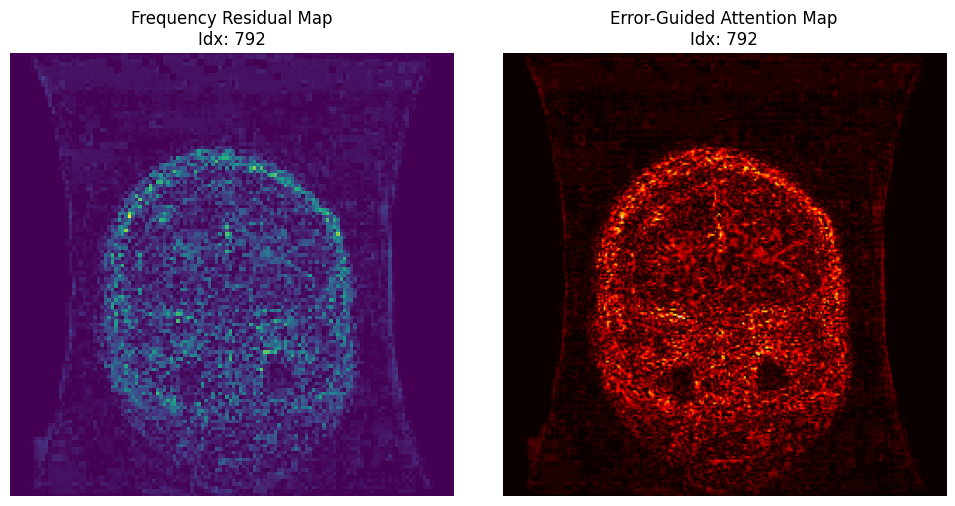

✅ Saved advanced visualization: /content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/advanced_visualizations/sample_792_advanced.png


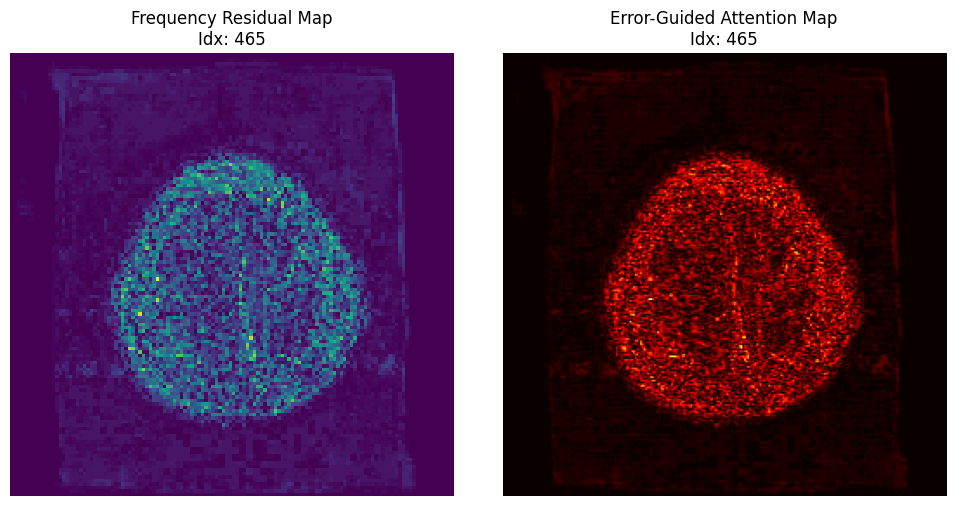

✅ Saved advanced visualization: /content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/advanced_visualizations/sample_465_advanced.png


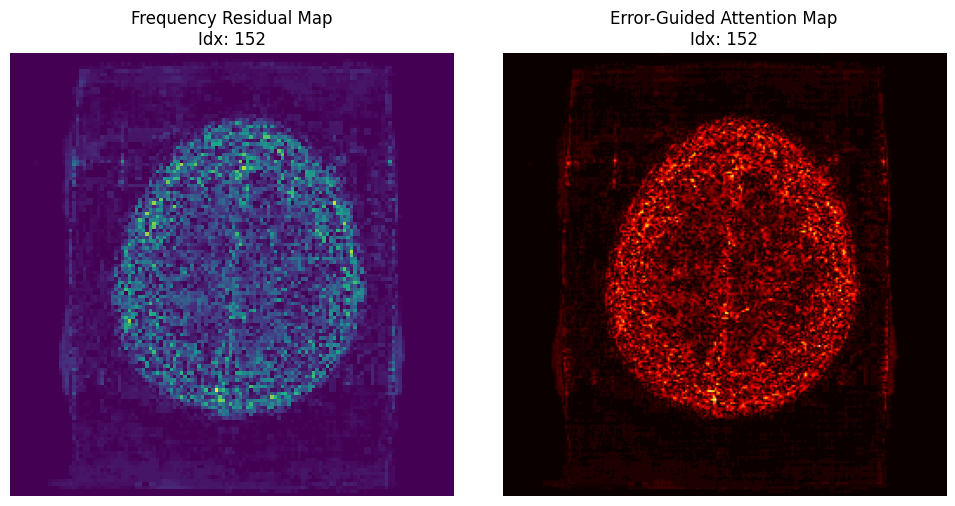

✅ Saved advanced visualization: /content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/advanced_visualizations/sample_152_advanced.png


In [ ]:
# ===========================
#  Cell 7.3: Display Frequency Residual & Error Attention Maps (Top-3 SSIM, Rician 0.03, No VAE)
# ===========================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import img_as_float
from pywt import dwt2
from IPython.display import display, Image

# --- Paths ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/without_vae_rician_0.03"
DENOISED_DIR = os.path.join(OUTPUT_DIR, "denoised_images")
NOISY_DIR    = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_vae_rician_0.03"
CLEAN_DIR    = "/content/drive/MyDrive/Final RI/glioma"
SAVE_DIR     = os.path.join(OUTPUT_DIR, "advanced_visualizations")
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Load metrics CSV and pick top-3 SSIM samples ---
metrics_csv = os.path.join(OUTPUT_DIR, "metrics_without_vae_rician_0.03.csv")
if not os.path.exists(metrics_csv):
    raise FileNotFoundError(f"Metrics CSV not found at {metrics_csv}. Run inference first.")
metrics_df = pd.read_csv(metrics_csv)
top_indices = metrics_df.sort_values("SSIM", ascending=False).head(3)["index"].tolist()

# --- Process top-3 samples ---
all_noisy_files = sorted(os.listdir(NOISY_DIR))

for idx in top_indices:
    if idx >= len(all_noisy_files):
        print(f" Index {idx} out of bounds for noisy images. Skipping.")
        continue

    base_name = all_noisy_files[idx]
    noisy_path    = os.path.join(NOISY_DIR, base_name)
    clean_path    = os.path.join(CLEAN_DIR, base_name)
    denoised_path = os.path.join(DENOISED_DIR, f"denoised_{idx:03d}.png")

    # --- Load images ---
    noisy    = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE) / 255.0
    clean    = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE) / 255.0
    denoised = cv2.imread(denoised_path, cv2.IMREAD_GRAYSCALE) / 255.0

    # --- Resize images to 256x256 ---
    if clean.shape != (256, 256):
        clean = cv2.resize(clean, (256, 256))
    if noisy.shape != (256, 256):
        noisy = cv2.resize(noisy, (256, 256))

    # --- Frequency-Domain Residual (DWT LL component) ---
    residual = clean - denoised
    LL, (LH, HL, HH) = dwt2(residual, 'haar')
    freq_map = np.abs(LL)
    freq_map = (freq_map - freq_map.min()) / (freq_map.max() - freq_map.min() + 1e-8)

    # --- Error-Guided Attention Map ---
    error_map = np.abs(residual)
    error_map = (error_map - error_map.min()) / (error_map.max() - error_map.min() + 1e-8)

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(freq_map, cmap='viridis')
    axes[0].set_title(f"Frequency Residual Map\nIdx: {idx}")
    axes[0].axis('off')

    axes[1].imshow(error_map, cmap='hot')
    axes[1].set_title(f"Error-Guided Attention Map\nIdx: {idx}")
    axes[1].axis('off')

    plt.tight_layout()

    # --- Save figure ---
    save_path = os.path.join(SAVE_DIR, f"sample_{idx:03d}_advanced.png")
    plt.savefig(save_path)
    plt.show()

    print(f" Saved advanced visualization: {save_path}")


✅ Loaded best generator: best_generator_epoch29_ssim0.9565.pt


🖼️ Running Inference (Rician without VAE): 100%|██████████| 1297/1297 [02:55<00:00,  7.37it/s]



📊 Final Validation Metrics (without VAE, Rician 0.03):
   Avg PSNR: 36.95 dB
   Avg SSIM: 0.9565
📁 Image panels saved to: /content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/image_panels
📁 Denoised images saved to: /content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/denoised_images
📄 Metrics CSV saved to: /content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/metrics_without_vae_rician_0.03.csv


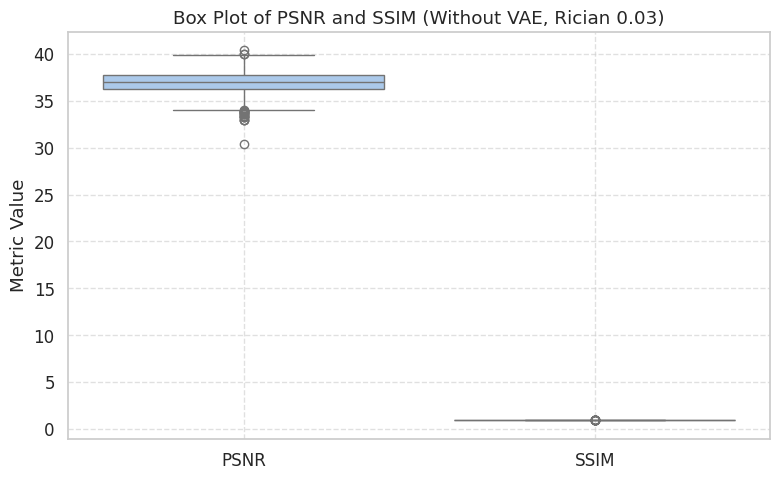

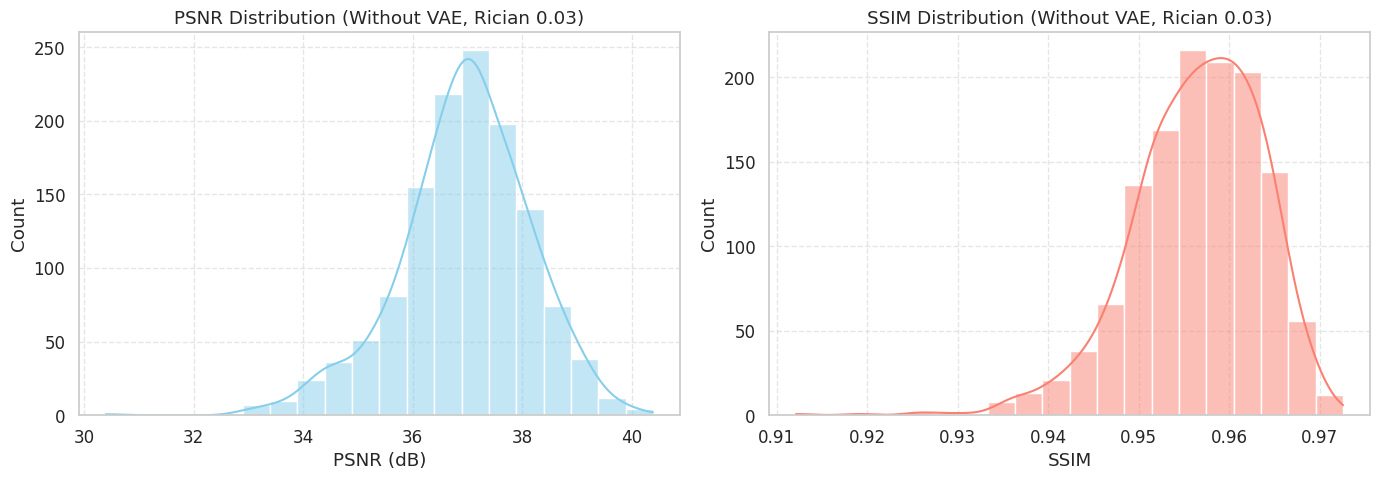

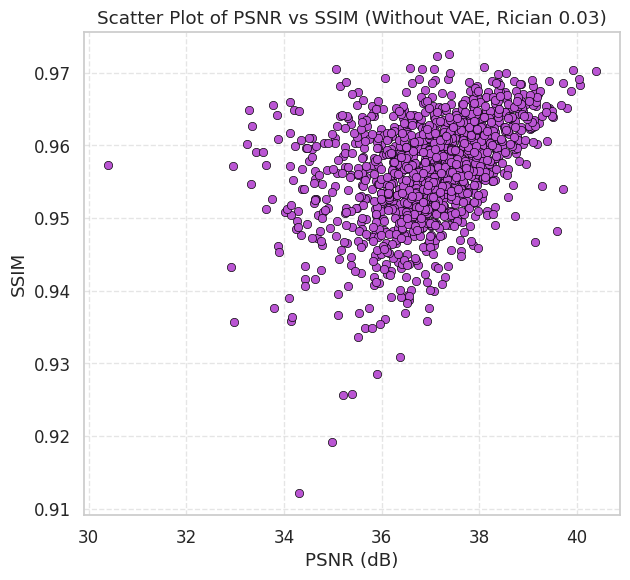


📊 Summary Statistics (Without VAE, Rician 0.03):
             PSNR      SSIM
mean    36.951139  0.956502
median  37.009816  0.957145
std      1.198883  0.007212


In [ ]:
# ===========================
#  Inference on Rician Denoising (PSNR/SSIM + Image Saving) – without VAE, σ=0.03
# ===========================

import os
import torch
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
import pandas as pd
from tqdm import tqdm
import numpy as np
import cv2
import glob
import seaborn as sns

# === Set output directories for this specific run ===
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/without_vae_rician_0.03"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SAVE_DIR = os.path.join(OUTPUT_DIR, "image_panels")
os.makedirs(IMG_SAVE_DIR, exist_ok=True)

DENOISED_DIR = os.path.join(OUTPUT_DIR, "denoised_images")
os.makedirs(DENOISED_DIR, exist_ok=True)

CLINICAL_DIR = os.path.join(OUTPUT_DIR, "clinical_panels")
os.makedirs(CLINICAL_DIR, exist_ok=True)

# --- Load the latest best-performing generator model from this run ---
best_model_path = max(glob.glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt")), key=os.path.getctime)
G.load_state_dict(torch.load(best_model_path))
G.eval()
print(f" Loaded best generator: {os.path.basename(best_model_path)}")

# --- Perform inference and compute evaluation metrics ---
metrics = []

with torch.no_grad():
    for i, (noisy_img, clean_img) in enumerate(tqdm(val_loader, desc=" Running Inference (Rician without VAE)")):
        noisy_img = noisy_img.cuda()
        clean_img = clean_img.cuda()
        denoised_img = G(noisy_img)  # baseline generator without VAE

        # Convert images to NumPy
        noisy_np = noisy_img.squeeze().cpu().numpy()
        clean_np = clean_img.squeeze().cpu().numpy()
        denoised_np = denoised_img.squeeze().cpu().numpy()

        # --- Compute PSNR and SSIM ---
        psnr = compute_psnr(clean_np, denoised_np, data_range=1.0)
        ssim = compute_ssim(clean_np, denoised_np, data_range=1.0)

        metrics.append({
            "index": i,
            "PSNR": psnr,
            "SSIM": ssim
        })

        # --- Save side-by-side comparison (Noisy | Denoised | Clean) ---
        comparison = torch.cat([noisy_img, denoised_img, clean_img], dim=0)
        grid = make_grid(comparison, nrow=3, normalize=True)
        save_image(grid, os.path.join(IMG_SAVE_DIR, f"sample_{i:03d}.png"))

        # --- Save only denoised image ---
        denoised_uint8 = (denoised_np * 255).astype(np.uint8)
        denoised_save_path = os.path.join(DENOISED_DIR, f"denoised_{i:03d}.png")
        cv2.imwrite(denoised_save_path, denoised_uint8)

# --- Store metrics in CSV ---
df_metrics = pd.DataFrame(metrics)
csv_path = os.path.join(OUTPUT_DIR, "metrics_without_vae_rician_0.03.csv")
df_metrics.to_csv(csv_path, index=False)

# --- Display average metrics ---
avg_psnr = df_metrics['PSNR'].mean()
avg_ssim = df_metrics['SSIM'].mean()
print(f"\n Final Validation Metrics (without VAE, Rician 0.03):")
print(f"   Avg PSNR: {avg_psnr:.2f} dB")
print(f"   Avg SSIM: {avg_ssim:.4f}")
print(f" Image panels saved to: {IMG_SAVE_DIR}")
print(f" Denoised images saved to: {DENOISED_DIR}")
print(f" Metrics CSV saved to: {csv_path}")

# ===========================
#  Visualization & Summary (PSNR/SSIM) – without VAE, Rician 0.03
# ===========================

# Set Seaborn style
sns.set(style="whitegrid", font_scale=1.1)

# --- Boxplot ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_metrics[["PSNR", "SSIM"]], palette="pastel")
plt.title("Box Plot of PSNR and SSIM (Without VAE, Rician 0.03)")
plt.ylabel("Metric Value")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(CLINICAL_DIR, "boxplot_psnr_ssim.png"))
plt.show()

# --- Histograms ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_metrics["PSNR"], bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title("PSNR Distribution (Without VAE, Rician 0.03)")
axes[0].set_xlabel("PSNR (dB)")
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(df_metrics["SSIM"], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title("SSIM Distribution (Without VAE, Rician 0.03)")
axes[1].set_xlabel("SSIM")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(CLINICAL_DIR, "histograms_psnr_ssim.png"))
plt.show()

# --- Scatter Plot PSNR vs SSIM ---
plt.figure(figsize=(6.5, 6))
sns.scatterplot(x="PSNR", y="SSIM", data=df_metrics, color='mediumorchid', edgecolor='black')
plt.title("Scatter Plot of PSNR vs SSIM (Without VAE, Rician 0.03)")
plt.xlabel("PSNR (dB)")
plt.ylabel("SSIM")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(CLINICAL_DIR, "scatter_psnr_vs_ssim.png"))
plt.show()

# --- Summary Statistics ---
summary_stats = df_metrics[["PSNR", "SSIM"]].agg(['mean', 'median', 'std'])
summary_stats.to_csv(os.path.join(CLINICAL_DIR, "summary_statistics.csv"))
print("\n Summary Statistics (Without VAE, Rician 0.03):")
print(summary_stats.round(6))


In [ ]:
# ===========================
#  Runtime Restore (Rician-Only Experiment, without VAE, σ=0.03)
# ===========================

import torch
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
import os, glob

# --- Reload Generator Definition ---
class UNetGenerator(torch.nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return torch.nn.Sequential(
                torch.nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                torch.nn.InstanceNorm2d(out_ch),
                torch.nn.LeakyReLU(0.2, inplace=True)
            )

        def up_block(in_ch, out_ch):
            return torch.nn.Sequential(
                torch.nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2),
                torch.nn.InstanceNorm2d(out_ch),
                torch.nn.ReLU(inplace=True)
            )

        # --- Encoder ---
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.pool = torch.nn.MaxPool2d(2)

        # --- Decoder ---
        self.up1 = up_block(512, 256)
        self.dec1 = conv_block(512, 256)

        self.up2 = up_block(256, 128)
        self.dec2 = conv_block(256, 128)

        self.up3 = up_block(128, 64)
        self.dec3 = conv_block(128, 64)

        self.out_conv = torch.nn.Conv2d(64, out_channels, kernel_size=1)


    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Decoder
        d1 = self.up1(e4)
        d1 = self.dec1(torch.cat([d1, e3], dim=1))

        d2 = self.up2(d1)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d3 = self.up3(d2)
        d3 = self.dec3(torch.cat([d3, e1], dim=1))

        out = torch.sigmoid(self.out_conv(d3))
        return out


# --- Reload Best Generator Weights (without VAE, σ=0.03) ---
SAVE_PATH = "/content/drive/MyDrive/Final RI/checkpoints/without_vae_rician_0.03"
best_model_path = max(glob.glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt")), key=os.path.getctime)
G = UNetGenerator().cuda()
G.load_state_dict(torch.load(best_model_path))
G.eval()
print(f" Loaded best generator (without VAE, Rician 0.03): {os.path.basename(best_model_path)}")

# --- Redefine Dataset Class ---
class MRIDenoisingDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, transform=None):
        noisy_all = sorted(glob.glob(os.path.join(noisy_dir, "*.*")))
        clean_all = sorted(glob.glob(os.path.join(clean_dir, "*.*")))
        noisy_dict = {os.path.basename(p): p for p in noisy_all}
        clean_dict = {os.path.basename(p): p for p in clean_all}
        common = sorted(set(noisy_dict.keys()) & set(clean_dict.keys()))
        self.noisy = [noisy_dict[f] for f in common]
        self.clean = [clean_dict[f] for f in common]
        self.transform = transform

    def __len__(self): return len(self.noisy)

    def __getitem__(self, idx):
        noisy = cv2.imread(self.noisy[idx], cv2.IMREAD_GRAYSCALE)
        clean = cv2.imread(self.clean[idx], cv2.IMREAD_GRAYSCALE)
        noisy = cv2.resize(noisy, (256, 256)).astype(np.float32) / 255.0
        clean = cv2.resize(clean, (256, 256)).astype(np.float32) / 255.0
        if self.transform:
            noisy = self.transform(noisy)
            clean = self.transform(clean)
        return noisy, clean

# --- Load val_loader again (without VAE, Rician 0.03 paths) ---
transform = transforms.ToTensor()
val_loader = DataLoader(
    MRIDenoisingDataset(
        "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_without_vae_rician_0.03",
        "/content/drive/MyDrive/Final RI/glioma",
        transform
    ),
    batch_size=1, shuffle=False
)

# --- Reload Top-10 SSIM indices from metrics for this run ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/without_vae_rician_0.03"
metrics_df = pd.read_csv(os.path.join(OUTPUT_DIR, "metrics_without_vae_rician_0.03.csv"))
selected_samples = metrics_df.sort_values("SSIM", ascending=False).head(10)["index"].tolist()
print(" Selected Top 10 Samples (by SSIM, without VAE, Rician 0.03):", selected_samples)

✅ Loaded best generator (without VAE, Rician 0.03): best_generator_epoch29_ssim0.9565.pt
📊 Selected Top 10 Samples (by SSIM, without VAE, Rician 0.03): [792, 465, 152, 522, 841, 199, 506, 514, 1244, 493]


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from IPython.display import Image, display

# --- Load metrics for without VAE, Rician σ=0.03 ---
metrics_df = pd.read_csv("/content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/metrics_without_vae_rician_0.03.csv")

# --- Load the noise log to get original filenames ---
NOISY_DIR = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_vae_rician_0.03"
csv_path = os.path.join(NOISY_DIR, "noise_log.csv")
log_df = pd.read_csv(csv_path)

# --- Top 10 SSIM samples ---
top_indices = metrics_df.sort_values("SSIM", ascending=False).head(10)["index"].tolist()

# --- Set paths (without VAE, Rician σ=0.03 dirs) ---
denoised_dir = "/content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/denoised_images"
noisy_dir    = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_vae_rician_0.03"
clean_dir    = "/content/drive/MyDrive/Final RI/glioma"
save_dir     = "/content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/visualization_panels"

# --- Create output folder if it doesn't exist ---
os.makedirs(save_dir, exist_ok=True)

# --- Helper functions ---
def compute_edge_diff(img1, img2):
    """Compute mean absolute edge map difference using Sobel."""
    sobelx1 = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
    sobely1 = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)
    edges1 = np.sqrt(sobelx1**2 + sobely1**2)

    sobelx2 = cv2.Sobel(img2, cv2.CV_64F, 1, 0, ksize=3)
    sobely2 = cv2.Sobel(img2, cv2.CV_64F, 0, 1, ksize=3)
    edges2 = np.sqrt(sobelx2**2 + sobely2**2)

    return np.mean(np.abs(edges1 - edges2))

def compute_laplacian_diff(img1, img2):
    """Compute difference in average Laplacian variance (sharpness)."""
    lap1 = cv2.Laplacian(img1, cv2.CV_64F).var()
    lap2 = cv2.Laplacian(img2, cv2.CV_64F).var()
    return abs(lap1 - lap2)

# --- Create single figure: 10 rows × 3 columns ---
fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(12, 40))
fig.subplots_adjust(hspace=0.6)

for row_idx, sample_idx in enumerate(top_indices):
    try:
        original_filename = log_df.loc[sample_idx, "filename"]
    except KeyError:
        print(f" Warning: Filename for index {sample_idx} not found. Skipping.")
        continue

    noisy_path    = os.path.join(noisy_dir, original_filename)
    clean_path    = os.path.join(clean_dir, original_filename)
    denoised_path = os.path.join(denoised_dir, f"denoised_{sample_idx:03d}.png")

    # Read images
    noisy    = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
    clean    = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)
    denoised = cv2.imread(denoised_path, cv2.IMREAD_GRAYSCALE)

    if noisy is None or clean is None or denoised is None:
        print(f" Skipping {sample_idx}, missing image(s).")
        continue

    # Resize and normalize
    noisy    = cv2.resize(noisy, (256, 256)) / 255.0
    clean    = cv2.resize(clean, (256, 256)) / 255.0
    denoised = cv2.resize(denoised, (256, 256)) / 255.0

    # --- Compute extra metrics ---
    edge_diff = compute_edge_diff(clean, denoised)
    lap_diff  = compute_laplacian_diff(clean, denoised)

    # --- Plot images ---
    axes[row_idx, 0].imshow(noisy, cmap='gray')
    axes[row_idx, 0].set_title(f" Noisy\nIdx: {sample_idx}")
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(denoised, cmap='gray')
    axes[row_idx, 1].set_title(" Denoised")
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(clean, cmap='gray')
    axes[row_idx, 2].set_title(" Ground Truth")
    axes[row_idx, 2].axis('off')

    # --- Add all metrics below row ---
    ssim = metrics_df.loc[sample_idx, "SSIM"]
    psnr = metrics_df.loc[sample_idx, "PSNR"]

    metrics_text = f"SSIM: {ssim:.4f} | PSNR: {psnr:.2f} dB\nEdgeDiff: {edge_diff:.4f} | LapDiff: {lap_diff:.4f}"
    axes[row_idx, 1].text(0.5, -0.25, metrics_text,
                          fontsize=9, ha='center', va='top', transform=axes[row_idx, 1].transAxes)

# --- Save full grid as one image ---
final_path = os.path.join(save_dir, "top10_visualization_with_edges_laplacian.png")
plt.tight_layout()
plt.savefig(final_path, dpi=150)
plt.close()

print(f" Saved full visualization with Edge/Laplacian (without VAE, Rician σ=0.03): {final_path}")
display(Image(filename=final_path))


Output hidden; open in https://colab.research.google.com to view.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


✅ Saved: /content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/visualization_panels/top10_visualization_with_edges_laplacian.png


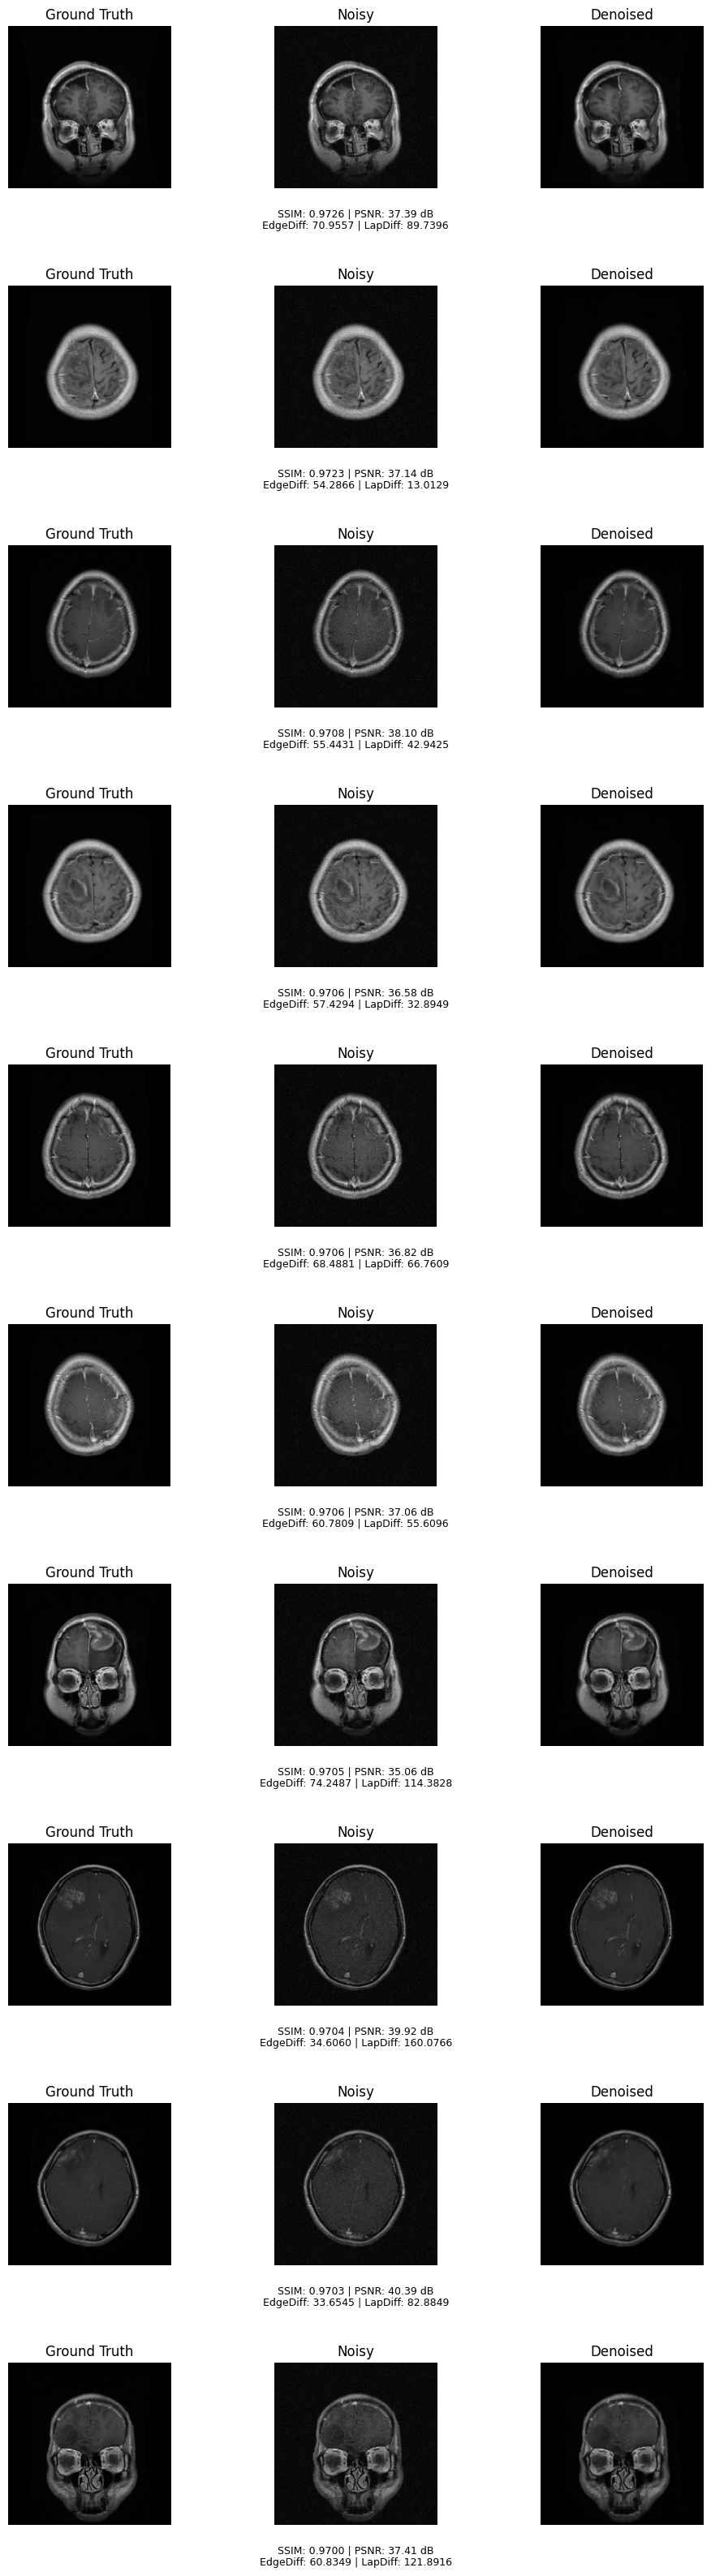

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from IPython.display import Image, display

# =========================
# Load metrics
# =========================
metrics_df = pd.read_csv(
    "/content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/metrics_without_vae_rician_0.03.csv"
)

# =========================
# Load noise log (for filenames)
# =========================
NOISY_DIR = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_vae_rician_0.03"
csv_path = os.path.join(NOISY_DIR, "noise_log.csv")
log_df = pd.read_csv(csv_path)

# =========================
# Top 10 SSIM samples
# =========================
top_indices = (
    metrics_df.sort_values("SSIM", ascending=False)
    .head(10)["index"]
    .tolist()
)

# =========================
# Paths
# =========================
denoised_dir = "/content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/denoised_images"
noisy_dir    = NOISY_DIR
clean_dir    = "/content/drive/MyDrive/Final RI/glioma"
save_dir     = "/content/drive/MyDrive/Final RI/results/without_vae_rician_0.03/visualization_panels"

os.makedirs(save_dir, exist_ok=True)

# =========================
# Image loader (NO modification)
# =========================
def load_image(path):
    if not os.path.exists(path):
        print("File not found:", path)
        return None

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Could not load:", path)
        return None

    return img  # original pixels only


# =========================
# Healthcare-safe size matching
# Crops to common center region
# NO resizing, NO interpolation
# =========================
def match_size_for_metrics(img1, img2):

    h1, w1 = img1.shape
    h2, w2 = img2.shape

    target_h = min(h1, h2)
    target_w = min(w1, w2)

    def center_crop(img, th, tw):
        h, w = img.shape
        start_h = (h - th) // 2
        start_w = (w - tw) // 2
        return img[start_h:start_h+th, start_w:start_w+tw]

    return center_crop(img1, target_h, target_w), center_crop(img2, target_h, target_w)


# =========================
# Metric helpers (healthcare-safe)
# =========================
def compute_edge_diff(img1, img2):

    img1, img2 = match_size_for_metrics(img1, img2)

    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    sobelx1 = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
    sobely1 = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)
    edges1 = np.sqrt(sobelx1**2 + sobely1**2)

    sobelx2 = cv2.Sobel(img2, cv2.CV_64F, 1, 0, ksize=3)
    sobely2 = cv2.Sobel(img2, cv2.CV_64F, 0, 1, ksize=3)
    edges2 = np.sqrt(sobelx2**2 + sobely2**2)

    return np.mean(np.abs(edges1 - edges2))


def compute_laplacian_diff(img1, img2):

    img1, img2 = match_size_for_metrics(img1, img2)

    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    lap1 = cv2.Laplacian(img1, cv2.CV_64F).var()
    lap2 = cv2.Laplacian(img2, cv2.CV_64F).var()

    return abs(lap1 - lap2)


# =========================
# Create visualization panel
# =========================
fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(12, 40))
plt.subplots_adjust(hspace=0.6, wspace=0.2)

for row_idx, sample_idx in enumerate(top_indices):

    if sample_idx not in log_df.index:
        print(f" Filename for index {sample_idx} not found.")
        continue

    original_filename = log_df.loc[sample_idx, "filename"]

    noisy_path    = os.path.join(noisy_dir, original_filename)
    clean_path    = os.path.join(clean_dir, original_filename)
    denoised_path = os.path.join(denoised_dir, f"denoised_{sample_idx:03d}.png")

    # Load original images
    noisy    = load_image(noisy_path)
    clean    = load_image(clean_path)
    denoised = load_image(denoised_path)

    if noisy is None or clean is None or denoised is None:
        print(f" Skipping {sample_idx}, missing image(s).")
        continue

    # =========================
    # Compute metrics (healthcare-safe)
    # =========================
    edge_diff = compute_edge_diff(clean, denoised)
    lap_diff  = compute_laplacian_diff(clean, denoised)

    # =========================
    # Plot images EXACTLY as saved
    # Order: Ground Truth → Noisy → Denoised
    # =========================
    images = [clean, noisy, denoised]
    titles = ["Ground Truth", "Noisy", "Denoised"]

    for col in range(3):
        axes[row_idx, col].axis("off")
        axes[row_idx, col].imshow(images[col], cmap="gray", vmin=0, vmax=255)
        axes[row_idx, col].set_title(titles[col], fontsize=12)

    # =========================
    # Show metrics
    # =========================
    ssim = metrics_df.loc[sample_idx, "SSIM"]
    psnr = metrics_df.loc[sample_idx, "PSNR"]

    metrics_text = (
        f"SSIM: {ssim:.4f} | PSNR: {psnr:.2f} dB\n"
        f"EdgeDiff: {edge_diff:.4f} | LapDiff: {lap_diff:.4f}"
    )

    axes[row_idx, 1].text(
        0.5, -0.25,
        metrics_text,
        fontsize=9,
        ha="center",
        transform=axes[row_idx, 1].transAxes
    )

# =========================
# Save + display
# =========================
final_path = os.path.join(
    save_dir,
    "top10_visualization_with_edges_laplacian.png"
)

plt.savefig(final_path, bbox_inches="tight")
plt.close()

print(" Saved:", final_path)
display(Image(filename=final_path))

In [5]:
# ===========================
# Cell 7.1: Advanced Frequency & Attention Visualization (Rician 0.03, No VAE)
# ===========================

import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import pywt
import pandas as pd
from IPython.display import Image, display

# --- Paths for saving visualizations ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/without_vae_rician_0.03"
VIS_DIR = os.path.join(OUTPUT_DIR, "advanced_visualizations")
os.makedirs(VIS_DIR, exist_ok=True)

# --- Define directories ---
DENOISED_DIR = os.path.join(OUTPUT_DIR, "denoised_images")
NOISY_DIR    = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_vae_rician_0.03"
CLEAN_DIR    = "/content/drive/MyDrive/Final RI/glioma"

# --- Load metrics CSV ---
metrics_csv = os.path.join(OUTPUT_DIR, "metrics_without_vae_rician_0.03.csv")
if not os.path.exists(metrics_csv):
    raise FileNotFoundError(f"Metrics CSV not found at {metrics_csv}. Run inference first.")
metrics_df = pd.read_csv(metrics_csv)

# --- Functions for visualization ---
def frequency_residual_map(residual):
    """DWT 2D residual map"""
    coeffs2 = pywt.dwt2(residual, 'haar')
    LL, (LH, HL, HH) = coeffs2
    res_map = np.stack([LL, LH, HL, HH], axis=-1)
    res_map = (res_map - res_map.min()) / (res_map.max() - res_map.min() + 1e-8)
    top = np.hstack([res_map[:,:,0], res_map[:,:,1]])
    bottom = np.hstack([res_map[:,:,2], res_map[:,:,3]])
    return np.vstack([top, bottom])

def error_attention_map(denoised, clean):
    """Normalized error map with jet colormap"""
    err = np.abs(clean - denoised)
    err_map = (err - err.min()) / (err.max() - err.min() + 1e-8)
    cmap = plt.get_cmap('jet')
    return cmap(err_map)[:,:,:3]

# --- Top 3 SSIM samples ---
top_indices = metrics_df.sort_values("SSIM", ascending=False).head(3).index.tolist()
all_noisy_files = sorted(os.listdir(NOISY_DIR))

for idx in top_indices:
    if idx >= len(all_noisy_files):
        print(f" Index {idx} out of bounds for noisy images. Skipping.")
        continue

    base_name = all_noisy_files[idx]
    noisy_path    = os.path.join(NOISY_DIR, base_name)
    clean_path    = os.path.join(CLEAN_DIR, base_name)
    denoised_path = os.path.join(DENOISED_DIR, f"denoised_{idx:03d}.png")

    if not (os.path.exists(noisy_path) and os.path.exists(clean_path) and os.path.exists(denoised_path)):
        print(f" Missing file(s) for index {idx}. Skipping.")
        continue

    # --- Load images ---
    noisy    = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)/255.0
    clean    = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)/255.0
    denoised = cv2.imread(denoised_path, cv2.IMREAD_GRAYSCALE)/255.0

    # Resize to 256x256
    if noisy.shape != (256,256):
        noisy = cv2.resize(noisy, (256,256))
    if clean.shape != (256,256):
        clean = cv2.resize(clean, (256,256))
    if denoised.shape != (256,256):
        denoised = cv2.resize(denoised, (256,256))

    # Residuals and visualizations
    residual = clean - denoised
    freq_map = frequency_residual_map(residual)
    att_map  = error_attention_map(denoised, clean)

    # --- Plot side-by-side (ORDER CHANGED ONLY HERE) ---
    fig, axes = plt.subplots(1, 5, figsize=(20,4))

    axes[0].imshow(clean, cmap='gray'); axes[0].set_title("Ground Truth"); axes[0].axis('off')
    axes[1].imshow(noisy, cmap='gray'); axes[1].set_title("Noisy"); axes[1].axis('off')
    axes[2].imshow(denoised, cmap='gray'); axes[2].set_title("Denoised"); axes[2].axis('off')
    axes[3].imshow(freq_map, cmap='gray'); axes[3].set_title("DWT Residual"); axes[3].axis('off')
    axes[4].imshow(att_map); axes[4].set_title("Error Attention"); axes[4].axis('off')

    ssim_val = metrics_df.loc[idx, "SSIM"]
    psnr_val = metrics_df.loc[idx, "PSNR"]
    plt.suptitle(f"Sample Index: {idx} | SSIM: {ssim_val:.4f} | PSNR: {psnr_val:.2f}")
    plt.tight_layout()

    # --- Save figure ---
    save_path = os.path.join(VIS_DIR, f"sample_{idx:03d}_advanced.png")
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f" Saved advanced visualization: {save_path}")

# --- Display top 3 images inline ---
for idx in top_indices:
    display(Image(filename=os.path.join(VIS_DIR, f"sample_{idx:03d}_advanced.png")))

Output hidden; open in https://colab.research.google.com to view.